# ABCD


We use the Python implementation of ABCD: ```pip install abcd-graph```

A faster version of ABCD is available in Julia: https://github.com/bkamins/ABCDGraphGenerator.jl

We illustrate the following:
* generate and visualize a few small ABCD graphs with various noise ($\xi$) parameter values
* generate a larger ABCD graph and look at the degree and community size distribution
* use ABCD to generate several graphs to compare graph clustering algorithms


In [1]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
%matplotlib inline
from collections import Counter
import partition_igraph
from sklearn.metrics import adjusted_mutual_info_score as AMI
from abcd_graph import ABCDGraph, ABCDParams


# (1) Small ABCD graphs with 100 nodes and varying $\xi$

The ABCD parameters used to generate those graphs are: 
* $n=100$ (number of nodes)
* $\gamma=2.5$ (a.k.a. as 't1')
* degree range [5,15]
* $\beta=1.5$ (a.k.a. as 't2')
* community size range [30,40]
* $\xi \in \{0.1, 0.2, 0.3, 0.4\}$

In [2]:
## Parameters

## number of nodes
n = 100

## degree distribution
gamma = 2.5 ## a.k.a. t1
delta = 5
Delta = 15

## community sizes distribution
beta = 1.5 ## a.k.a. t2
s = 30
S = 40


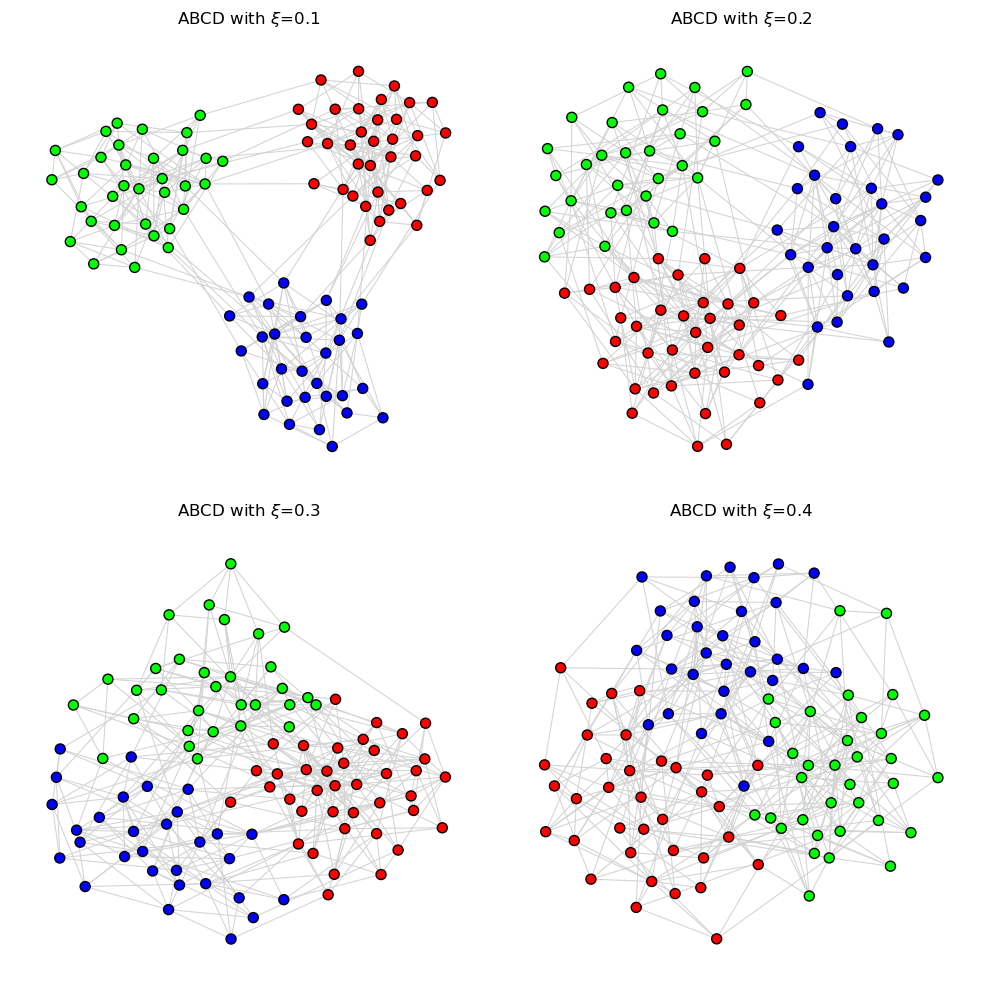

In [3]:
## Noise parameter values
xi_values = [0.1,0.2,0.3,0.4]

fig, axs = plt.subplots(2, 2, figsize=(10, 10)) # You can adjust figsize as needed

## for reproducibility
random.seed(123)
np.random.seed(123)

for i in range(4):
    params = ABCDParams(vcount=n, gamma=gamma, min_degree=delta, max_degree=Delta, beta=beta, 
                        min_community_size=s, max_community_size=S, xi=xi_values[i])
    g = ABCDGraph(params).build()
    g_abcd = g.exporter.to_igraph()

    g_abcd.vs['size'] = 10
    g_abcd.es['width'] = .75
    g_abcd.es['color'] = 'lightgrey'
    pal = ig.RainbowPalette(n=max(g_abcd.vs['ground_truth_community'])+1)
    g_abcd.vs['color'] = [pal[i] for i in g_abcd.vs['ground_truth_community']]
    ly = g_abcd.layout_fruchterman_reingold()
    ig.plot(g_abcd, target=axs[i//2,i%2], layout=ly, bbox=(0,0,400,300), Caption="Graph"+str(i))
    axs[i//2,i%2].set_title(r"ABCD with $\xi$="+str(xi_values[i]))
plt.tight_layout()
plt.show()

# (2) Larger ABCD graph - look at degree and community size distributions

The ABCD parameters used to generate this graph: 
* $n=1000000$ (number of nodes)
* $\gamma=2.5$ (a.k.a. as 't1')
* degree range [5,250]
* $\beta=1.5$ (a.k.a. as 't2')
* community size range [500,10000]
* $\xi = 0.2$

In [4]:
## Parameters

## number of nodes
n = 1000000

## degree distribution
gamma = 2.5
delta = 5
Delta = 250

## community sizes distribution
beta = 1.5
s = 500
S = 10000

## noise parameter
xi = 0.2

## for reproducibility
random.seed(321)
np.random.seed(321)

params = ABCDParams(vcount=n, gamma=gamma, min_degree=delta, max_degree=Delta, beta=beta, 
                    min_community_size=s, max_community_size=S, xi=xi)
g = ABCDGraph(params).build()
g_abcd = g.exporter.to_igraph()


min degree: 5 ; mean degree: 11.75439 ; max degree: 250


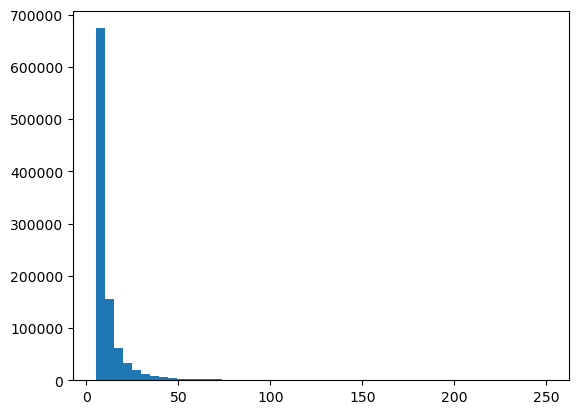

In [5]:
## degree distribution
D = g_abcd.degree()
print('min degree:',np.min(D),'; mean degree:',np.mean(D),'; max degree:',np.max(D))
plt.hist(g_abcd.degree(), bins=50);


min size: 503 ; mean size: 2070.3933747412007 ; max size: 9859


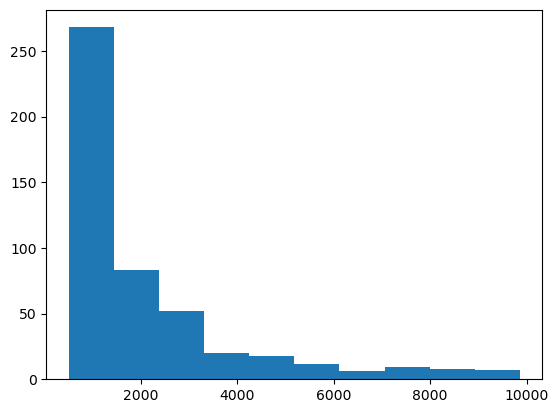

In [6]:
## community size distribution
C = list(Counter(g_abcd.vs['ground_truth_community']).values())
print('min size:',np.min(C),'; mean size:',np.mean(C),'; max size:',np.max(C))
plt.hist(C, bins=10);


# ABCD with varying $\xi$ -- Experiments

Here we show a typical way to compare graph clustering algorithms using ABCD graphs. 
We fix all other parameters while we vary the noise parameter $\xi$. 

For each choice of $\xi$, we generate 15 graphs, apply several different clustering algorithms,
and compute the AMI (adjusted mutual information) for each algorithm when comparing with the ground-truth communities.

Parameters for the ABCD benchmark graphs are:

* $n=1,000$
* $\gamma=2.5$ (a.k.a. as 't1')
* $\beta=1.5$ (a.k.a. as 't2')
* degree range [10,50]
* community size range [50,100]
* $0.3 \le \xi \le 0.8$


In the first plot below, we show the **mean** AMI values over the repeated tests. We see good results with Infomap, and slightly better results with Leiden and ECG. Label propagation is a fast algortihm, but it does collapse under moderate to high level of noise.

In the second plot, we show the **standard deviations** of the repeated tests. We see higher variability around the value(s) for $\xi$ where the different algorithms start to collapse.

Such studies are useful to compare algorithms; using ABCD, we can directly control parameters such as the noise level.


In [7]:
%%time
## common ABCD graph parameters

n = 1000

## degrees
gamma = 2.5
delta = 10
Delta = 50

## communities
beta = 1.5
s = 50
S = 100

## generate the graphs and run various clustering algorithms
random.seed(1234)
np.random.seed(1234)

## reduce the number of repeats for a faster run
REP = 15

## Loop and store results
L = []
for xi in np.arange(.3,.801,.05):
    for rep in range(REP):
        
        params = ABCDParams(vcount=n, gamma=gamma, min_degree=delta, max_degree=Delta, beta=beta, 
                            min_community_size=s, max_community_size=S, xi=xi)
        g = ABCDGraph(params).build()
        G = g.exporter.to_igraph()

        v = [xi, AMI(G.community_leiden(objective_function='modularity').membership, G.vs['ground_truth_community']),
             AMI(G.community_ecg(ens_size=16, final='leiden').membership, G.vs['ground_truth_community']),
             AMI(G.community_infomap().membership, G.vs['ground_truth_community']),
             AMI(G.community_label_propagation().membership, G.vs['ground_truth_community'])
            ]
        L.append(v)
df = pd.DataFrame(L, columns=['xi', 'leiden','ecg','infomap','lp'])


CPU times: user 56.9 s, sys: 814 ms, total: 57.7 s
Wall time: 57.9 s


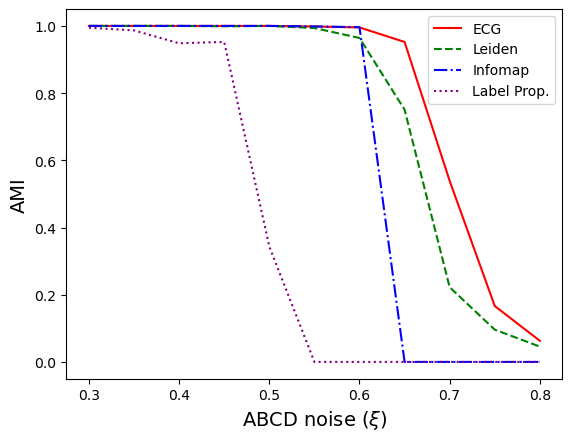

In [8]:
## mean AMI for various noise values
cls = ['red','green','blue','purple']
lt = ['-','--','-.',':']
D = df.groupby('xi', as_index=False).mean()
plt.plot(D.xi,D.ecg,lt[0],label='ECG',color=cls[0])
plt.plot(D.xi,D.leiden,lt[1],label='Leiden',color=cls[1])
plt.plot(D.xi,D.infomap,lt[2],label='Infomap',color=cls[2])
plt.plot(D.xi,D.lp,lt[3],label='Label Prop.',color=cls[3])
plt.xlabel(r'ABCD noise ($\xi$)', fontsize=14)
plt.ylabel('AMI', fontsize=14)
plt.legend()
#plt.savefig('abcd_study.eps')
plt.show()


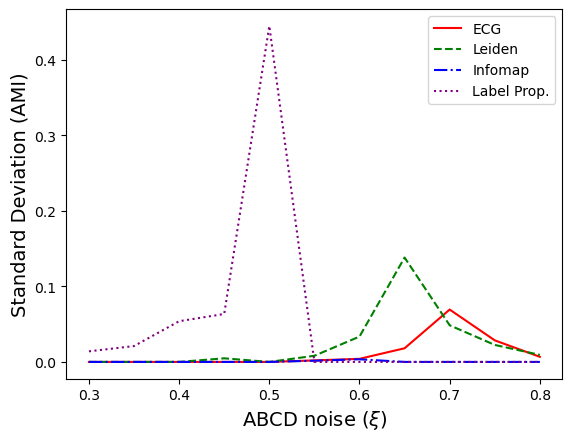

In [9]:
## Standard deviation AMI for various noise values
D = df.groupby('xi', as_index=False).std()
plt.plot(D.xi,D.ecg,lt[0],label='ECG',color=cls[0])
plt.plot(D.xi,D.leiden,lt[1],label='Leiden',color=cls[1])
plt.plot(D.xi,D.infomap,lt[2],label='Infomap',color=cls[2])
plt.plot(D.xi,D.lp,lt[3],label='Label Prop.',color=cls[3])
plt.xlabel(r'ABCD noise ($\xi$)', fontsize=14)
plt.ylabel('Standard Deviation (AMI)', fontsize=14)
plt.legend()
#plt.savefig('abcd_study_stdv.eps')
plt.show()
